In [ ]:
#Name - Atharv Kashiv
#roll - 2501940030

# ================================
# EXPERIMENT 3: LSTM (Time Series)
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load dataset (example: stock prices)

from google.colab import files
uploaded = files.upload()




Saving acwv.us.txt.txt to acwv.us.txt (1).txt


In [6]:
df = pd.read_csv("acwv.us.txt (1).txt")
data = df['Close'].values.reshape(-1,1)

# Normalize
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Create sequences
def create_seq(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 50
X, y = create_seq(data, seq_length)

# Split
split = int(0.8*len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0457 - val_loss: 0.0257
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0029 - val_loss: 0.0047
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 9.8458e-04 - val_loss: 6.9014e-04
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.1932e-04 - val_loss: 7.8844e-04
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.6749e-04 - val_loss: 7.4631e-04
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 4.4838e-04 - val_loss: 7.0872e-04
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 4.4269e-04 - val_loss: 7.3016e-04
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.3434e-04 - val_loss: 7.4203e-04
Epoch 9/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.2539e-04 - val_loss: 6.5413e-04
Epoch 10/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.2374e-04 - val_loss: 6.4087e-04
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


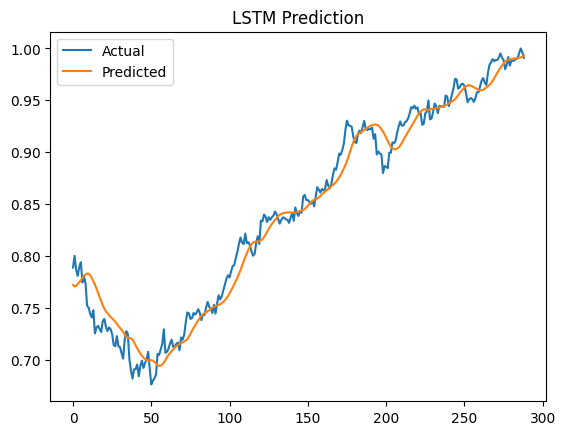

In [7]:
# ================================
# Model
# ================================
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(seq_length,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)

# Predict
pred = model.predict(X_test)

# Plot
plt.plot(y_test, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("LSTM Prediction")
plt.show()